# Pairs Trading Strategy: Coca-Cola vs Pepsi
## Author : Toby Newman
### Date: July 2026

## 1. Introduction

Pairs trading is a market-neutral statistical arbitrage strategy that seeks to profit from temporary deviations in the historical relationship between two correlated assets. When the price relationship moves significantly away from its historical average, the strategy assumes that it will eventually revert, creating potential trading opportunities.

This project implements a complete pairs trading strategy using Coca-Cola (KO) and Pepsi (PEP), two companies with similar business models and historically correlated share prices. The strategy uses rolling statistics and z-scores to generate trading signals, before evaluating its performance through backtesting, risk metrics and trade statistics.

## 2. Import Libraries
Import the libraries required for data collection, analysis and visualisation.

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display, HTML

## 3. Functions

### 3.1 Data Collection
Download and prepare the historical price data used throughout the trading strategy.

In [8]:
def get_data(ticker, start, end):
    """Download daily adjusted stock price data from Yahoo Finance."""
    data = yf.download(ticker, start=start, end=end, interval='1d', auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.droplevel('Ticker')
    return data.dropna()

In [9]:
def prepare_data(ticker, start, end):
    """Prepares the data in a single function."""
    data = get_data(ticker, start, end)
    data = calculate_returns(data)
    return data

### 3.2 Feature Engineering
Calculate the ratio, rolling statistics and z-score used to identify trading opportunities.

In [11]:
def calculate_returns(data):
    """Calculate returns from daily stock closing price."""
    data = data.copy()
    data['Return'] = data['Close'].pct_change()
    return data

In [12]:
def calculate_ratio(stock_x, stock_y):
    """Calculate the ratio of two stock closing prices."""
    ratio = stock_x['Close'] / stock_y['Close']
    return ratio.dropna()

In [13]:
def calculate_rolling_stats(ratio, window):
    """Calculate the rolling mean and standard deviation."""
    rolling_mean = ratio.rolling(window).mean()
    rolling_std = ratio.rolling(window).std()
    return rolling_mean, rolling_std

In [14]:
def calculate_z_score(ratio, rolling_mean, rolling_std):
    """Calculate the z-score using 'calculate_rolling_stats'."""
    rolling_std = rolling_std.replace(0, np.nan)
    z_score = (ratio - rolling_mean) / rolling_std
    return z_score.dropna()

### 3.3 Trading Logic
Generate entry and exit signals and convert them into daily trading positions.

In [16]:
def generate_signals(z_score, entry_threshold):
    """Generates the signals used in the z-score graph."""
    signal = pd.Series(0, index=z_score.index)
    short_entry = (z_score > entry_threshold) & (z_score.shift(1) <= entry_threshold)
    long_entry = (z_score < -entry_threshold) & (z_score.shift(1) >= -entry_threshold)
    signal[short_entry] = -1
    signal[long_entry] = 1
    return signal

In [17]:
def generate_positions(z_score, signals, exit_threshold):
    """Generate a daily position series (-1, 0, 1) from the trading signals."""
    position = pd.Series(0, index=z_score.index)
    current_position = 0
    for date in z_score.index:
        if current_position == 0:
            if signals.loc[date] == 1:
                current_position = 1
            elif signals.loc[date] == -1:
                current_position = -1

        elif current_position == 1:
            if z_score.loc[date] >= -exit_threshold:
                current_position = 0

        elif current_position == -1:
            if z_score.loc[date] <= exit_threshold:
                current_position = 0

        position.loc[date] = current_position

    return position

### 3.4 Visualisation
Plot the key variables used to analyse the strategy and its performance.

In [19]:
def plot_ratio(ratio, ticker_x, ticker_y, rolling_mean, rolling_std, entry_threshold):
    """Plot the price ratio with its rolling mean and standard deviation bands."""
    upper_band = rolling_mean + entry_threshold * rolling_std
    lower_band = rolling_mean - entry_threshold * rolling_std

    plt.figure(figsize=(15, 6))
    plt.title(f"{ticker_x}/{ticker_y} Price Ratio")

    # Normal trading range
    plt.fill_between(
        ratio.index,
        lower_band,
        upper_band,
        color="lightgrey",
        alpha=0.25,
        label="Normal Range")

    # Price ratio
    plt.plot(
        ratio,
        color="black",
        linewidth=1.5,
        label=f"{ticker_x}/{ticker_y} Ratio")

    # Rolling mean
    plt.plot(
        rolling_mean,
        color="royalblue",
        linewidth=2,
        label="Rolling Mean")

    # Upper and lower bands
    plt.plot(
        upper_band,
        color="darkorange",
        linestyle="--",
        linewidth=1.5,
        label=f"+{entry_threshold}σ Band")

    plt.plot(
        lower_band,
        color="darkorange",
        linestyle="--",
        linewidth=1.5,
        label=f"-{entry_threshold}σ Band")

    plt.xlabel("Date")
    plt.ylabel("Price Ratio")

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [20]:
def plot_z_score(z_score, signals, entry_threshold):
    """Plot the z-score with long and short trading signals."""
    plt.figure(figsize=(15, 6))
    plt.title("Z-Score and Trading Signals")

    # Normal trading range
    plt.axhspan(
        -entry_threshold,
        entry_threshold,
        color="lightgrey",
        alpha=0.25,
        label="Normal Range")

    # Z-score
    plt.plot(
        z_score,
        color="black",
        linewidth=1.5,
        label="Z-Score")

    # Entry thresholds and mean
    plt.axhline(
        entry_threshold,
        color="darkorange",
        linestyle="--",
        linewidth=1.5,
        label=f"+{entry_threshold} Entry Threshold")

    plt.axhline(
        0,
        color="royalblue",
        linestyle="-",
        linewidth=1.5,
        label="Mean")

    plt.axhline(
        -entry_threshold,
        color="darkorange",
        linestyle="--",
        linewidth=1.5,
        label=f"-{entry_threshold} Entry Threshold")

    # Identify trading signals
    short_signals = signals == -1
    long_signals = signals == 1

    # Plot short signals
    plt.scatter(
        z_score.index[short_signals],
        z_score[short_signals],
        color="red",
        marker="v",
        s=70,
        zorder=3,
        label="Short Ratio")

    # Plot long signals
    plt.scatter(
        z_score.index[long_signals],
        z_score[long_signals],
        color="green",
        marker="^",
        s=70,
        zorder=3,
        label="Long Ratio")

    plt.xlabel("Date")
    plt.ylabel("Z-Score")

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [21]:
def plot_equity_curve(equity_curve):
    """Plot the cumulative equity curve of the trading strategy."""
    starting_equity = equity_curve.iloc[0]
    ending_equity = equity_curve.iloc[-1]

    plt.figure(figsize=(15, 6))
    plt.title("Pairs Trading Strategy Equity Curve")

    # Shade gains and losses relative to starting equity
    plt.fill_between(
        equity_curve.index,
        starting_equity,
        equity_curve,
        where=equity_curve >= starting_equity,
        color="green",
        alpha=0.12)

    plt.fill_between(
        equity_curve.index,
        starting_equity,
        equity_curve,
        where=equity_curve < starting_equity,
        color="red",
        alpha=0.12)

    # Equity curve
    plt.plot(
        equity_curve,
        color="royalblue",
        linewidth=2,
        label="Strategy Equity")

    # Starting equity reference line
    plt.axhline(
        starting_equity,
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label="Starting Equity")

    # Mark final value
    plt.scatter(
        equity_curve.index[-1],
        ending_equity,
        color="black",
        s=45,
        zorder=3)

    plt.annotate(
        f"{ending_equity:.2f}",
        xy=(equity_curve.index[-1], ending_equity),
        xytext=(-10, 10),
        textcoords="offset points",
        ha="right",
        fontweight="bold",
        fontsize=20)

    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3.5 Backtesting
Simulate the trading strategy and calculate the resulting daily returns and equity curve.

In [23]:
def backtest_strategy(data_x, data_y, positions, cost):
    """Backtests the pairs trading strategy by calculating daily returns from 
    the generated trading positions."""
    returns = pd.concat(
        [data_x['Return'], data_y['Return']], axis=1).dropna()
    returns.columns = ['x_return', 'y_return']
    positions = positions.reindex(returns.index)
    pair_return = 0.5 * positions.shift(1) * (returns['x_return'] - returns['y_return'])
    
    trades = positions.diff().abs()
    strategy_return = pair_return - trades * cost
    strategy_return = strategy_return.fillna(0)
    
    equity_curve = (1 + strategy_return).cumprod()
    
    return strategy_return, equity_curve

### 3.6 Performance Metrics
Calculate summary statistics used to evaluate the overall performance of the trading strategy.

In [25]:
def calculate_sharpe(strategy_return, risk_free_rate=0):
    """Calculate the annualised Sharpe ratio from daily strategy returns."""
    daily_risk_free_rate = risk_free_rate / 252
    excess_return = strategy_return - daily_risk_free_rate

    if excess_return.std() == 0:
        return np.nan
        
    sharpe_ratio = (excess_return.mean() / excess_return.std() * np.sqrt(252))
    return sharpe_ratio

In [26]:
def calculate_annualised_return(equity_curve):
    """Calculates the compound annual growth rate (CAGR) from the strategy's equity curve."""
    years = len(equity_curve) / 252
    start = equity_curve.iloc[0]
    end = equity_curve.iloc[-1]
    cagr = (end / start) ** (1 / years) - 1
    return cagr

In [27]:
def calculate_drawdown(equity_curve):
    """Calculates the maximum drawdown from the strategy's equity curve."""
    peak = equity_curve.cummax()
    drawdown = (equity_curve - peak) / peak
    return drawdown.min()

In [28]:
def calculate_volatility(strategy_return):
    """Calculates the annualised volatility of the trading strategy."""
    return strategy_return.std() * np.sqrt(252)

### 3.7 Trade Statistics
Calculate statistics describing the performance of individual completed trades.

In [30]:
def calculate_trade_returns(positions, strategy_return):
    """Calculates the return of each completed trade."""

    trade_returns = []
    entry_date = None
    position_changes = positions.diff()

    for i in range(1, len(positions)):
        if position_changes.iloc[i] != 0 and positions.iloc[i] != 0:
            entry_date = positions.index[i]
        
        elif (
            position_changes.iloc[i] != 0
            and positions.iloc[i] == 0
            and entry_date is not None):
            
            exit_date = positions.index[i]

            trade_return = (
                1 + strategy_return.loc[entry_date:exit_date]
            ).prod() - 1
            
            trade_returns.append(trade_return)
            entry_date = None
    
    if entry_date is not None:
        exit_date = positions.index[-1]
        trade_return = (
            1 + strategy_return.loc[entry_date:exit_date]
        ).prod() - 1
        trade_returns.append(trade_return)
        
    return trade_returns

In [31]:
def calculate_win_rate(trade_returns):
    """Calculates the proportion of completed trades that were profitable."""
    winning_trades = 0
    for trade in trade_returns:
        if trade > 0:
            winning_trades += 1
        
    win_rate = winning_trades / len(trade_returns)
    return win_rate

In [32]:
def calculate_average_winner(trade_returns):
    """Calculates the average return of all profitable completed trades."""
    total_winning_return = 0
    winning_trades = 0
    for trade in trade_returns:
        if trade > 0:
            total_winning_return += trade
            winning_trades += 1
    if winning_trades == 0:
        return np.nan

    average_winner = total_winning_return / winning_trades
    return average_winner

In [33]:
def calculate_average_loser(trade_returns):
    """Calculates the average return of all losing completed trades."""
    total_losing_return = 0
    losing_trades = 0
    for trade in trade_returns:
        if trade < 0:
            total_losing_return += trade
            losing_trades += 1
    if losing_trades == 0:
        return np.nan

    average_loser = total_losing_return / losing_trades
    return average_loser

In [34]:
def calculate_best_trade(trade_returns):
    """Calculates the return of the most profitable completed trade."""
    if len(trade_returns) == 0:
        return np.nan
    
    return max(trade_returns)

In [35]:
def calculate_worst_trade(trade_returns):
    """Calculates the return of the least profitable completed trade."""
    if len(trade_returns) == 0:
        return np.nan
        
    return min(trade_returns)

In [36]:
def calculate_profit_factor(trade_returns):
    """Calculates the ratio of gross profits to gross losses across all completed trades."""
    if len(trade_returns) == 0:
        return np.nan
    gross_profit = 0
    gross_loss = 0
    for trade in trade_returns:
        if trade > 0:
            gross_profit += trade
        elif trade < 0:
            gross_loss += trade
    if gross_loss == 0:
        return np.inf
    return gross_profit / abs(gross_loss)

## 4. Strategy Parameters

Define the assets, time period and trading parameters used throughout the pairs trading strategy. These values control the rolling statistics, trading thresholds and transaction costs applied during the backtest.

In [38]:
# Select the two stocks used in the pairs trading strategy.
# Here, 'KO' represents Coca-Cola and 'PEP' represents Pepsi.
ticker_x = 'KO'
ticker_y = 'PEP'

# Define the historical period over which the strategy will be tested.
start = '2015-01-01'
end = '2026-01-01'

# The rolling window used to calculate the rolling mean and standard deviation
# of the price ratio.
window = 20

# Transaction cost applied per unit change in position (0.1%).
cost = 0.001

# Entry and exit thresholds based on the z-score.
# Positions are opened when the entry threshold is crossed and closed
# when the z-score returns to the exit threshold.
entry_threshold = 2
exit_threshold = 0

## 5. Data Preparation

Retrieve the historical price data and calculate the variables required for the pairs trading strategy.

### Prepare Historical Market Data

In [41]:
# Download and prepare both datasets
data_x = prepare_data(ticker_x, start, end)
data_y = prepare_data(ticker_y, start, end)

### Calculate Trading Variables

In [43]:
# Calculate the price ratio
ratio = calculate_ratio(data_x, data_y)
# Calculate rolling statistics
rolling_mean, rolling_std = calculate_rolling_stats(ratio, window)
# Calculate the z-score
z_score = calculate_z_score(ratio, rolling_mean, rolling_std)

### Generate Trading Signals

In [45]:
# Generate trading signals
signals = generate_signals(z_score, entry_threshold)
# Generate trading positions
positions = generate_positions(z_score, signals, exit_threshold)

## 6. Visualisations

Visualise the price relationship between Coca-Cola and Pepsi and the trading signals generated by the strategy.

### Price Ratio and Rolling Statistics

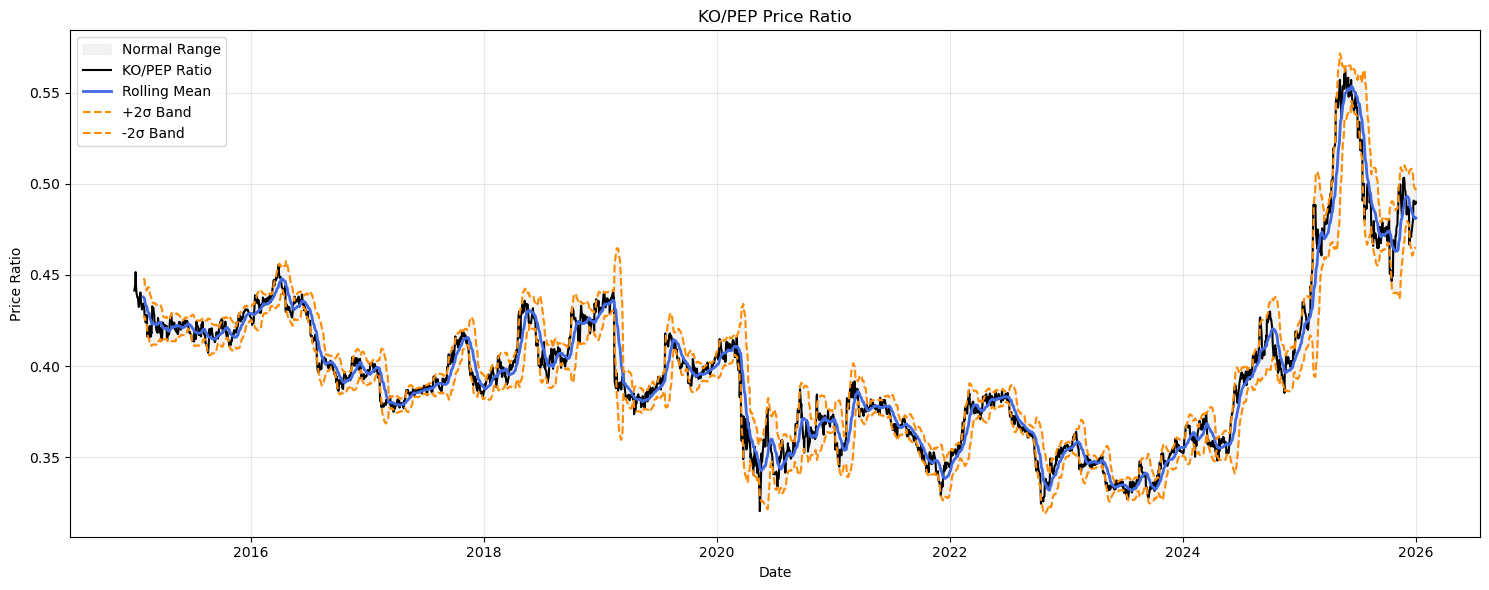

In [48]:
# Plot the price ratio with its rolling statistics.
plot_ratio(ratio, ticker_x, ticker_y, rolling_mean, rolling_std, entry_threshold)

### Z-Score and Trading Signals

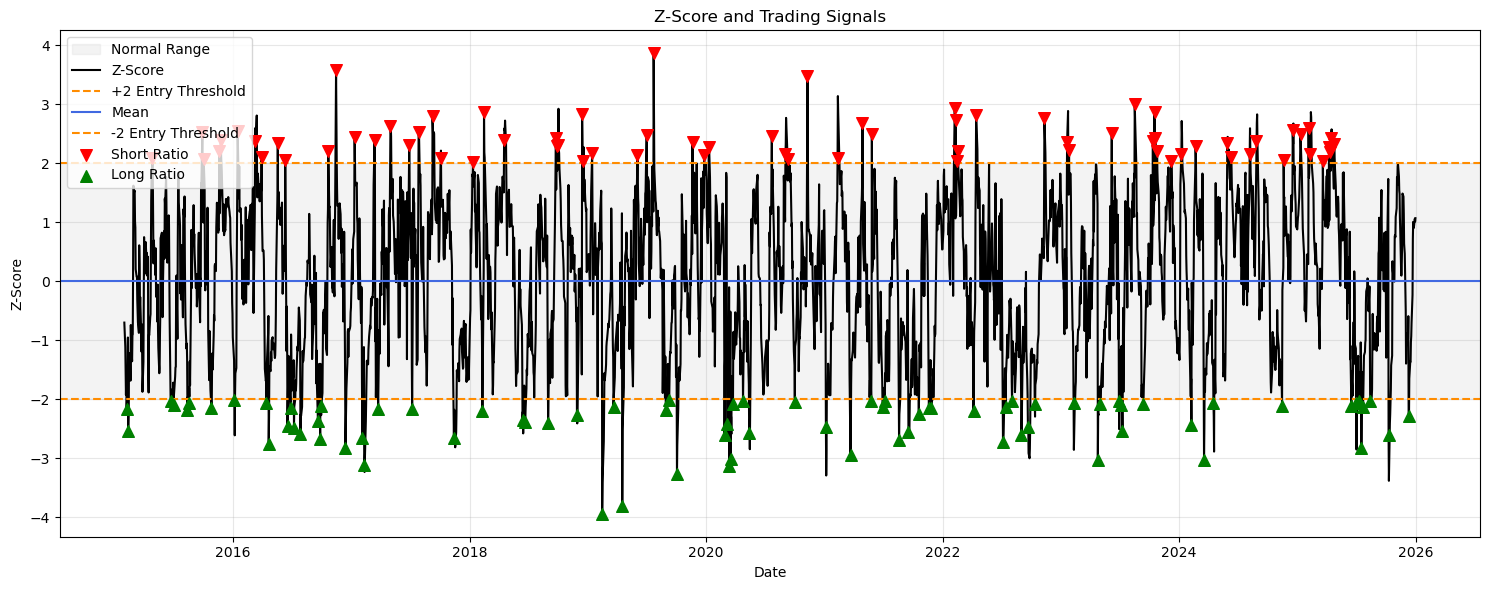

In [50]:
# Plot the z-score with the long and short entry signals.
plot_z_score(z_score, signals, entry_threshold)

## 7. Backtesting

Simulate the performance of the pairs trading strategy using the generated trading positions. The cumulative returns are calculated after transaction costs.

In [53]:
strategy_return, equity_curve = backtest_strategy(data_x, data_y, positions, cost)

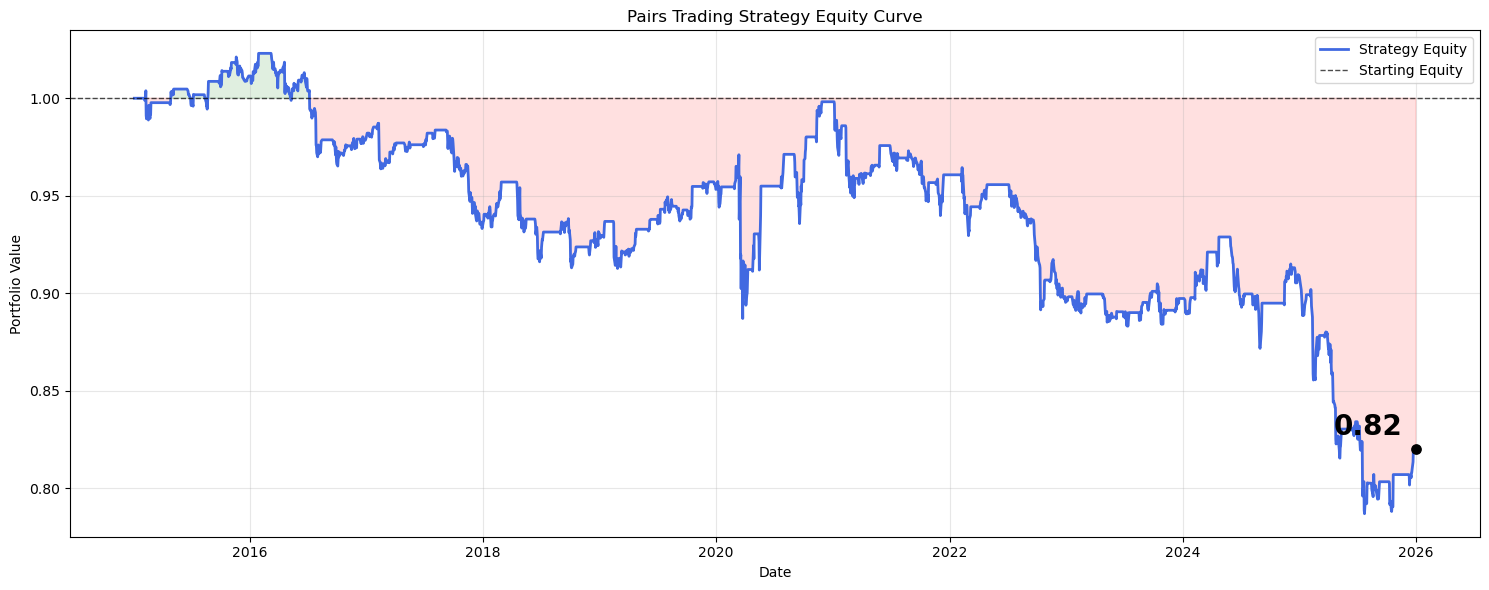

In [54]:
plot_equity_curve(equity_curve)

The equity curve provides a visual summary of the strategy's cumulative performance throughout the backtest period after transaction costs.

## 8. Performance Metrics

Evaluate the performance and risk of the pairs trading strategy using the daily strategy returns and cumulative equity curve.

In [57]:
# Calculate performance metrics
total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0]) - 1
annualised_return = calculate_annualised_return(equity_curve)
annualised_volatility = calculate_volatility(strategy_return)
sharpe_ratio = calculate_sharpe(strategy_return)
max_drawdown = calculate_drawdown(equity_curve)

In [58]:
# Display performance statistics
performance_metrics = pd.DataFrame(
    {
        "Value": [
            f"{total_return:.2%}",
            f"{annualised_return:.2%}",
            f"{annualised_volatility:.2%}",
            f"{sharpe_ratio:.2f}",
            f"{max_drawdown:.2%}"
        ]
    },
    index=[
        "Total Return",
        "Annualised Return",
        "Annualised Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ]
)
display(Markdown("### Performance Metrics"))
display(performance_metrics)

### Performance Metrics

,Value
Total Return,-17.99%
Annualised Return,-1.79%
Annualised Volatility,5.15%
Sharpe Ratio,-0.33
Maximum Drawdown,-23.07%


The strategy generated a total return of -17.99%, corresponding to an annualised return of -1.79% over the backtest period. The annualised volatility of 5.15% indicates that returns were relatively stable; however, this low level of risk was accompanied by poor performance. The Sharpe ratio of -0.33 suggests that the strategy failed to produce positive risk-adjusted returns, while the maximum drawdown of -23.07% highlights that the portfolio experienced a substantial decline from its peak value. Overall, these metrics indicate that the strategy was not profitable over the selected sample period.

## 9. Trade Statistics

Analyse the characteristics of individual trades generated by the pairs trading strategy. These statistics provide additional insight into trading performance beyond the overall portfolio returns.

In [61]:
# Calculate returns for each trade
trade_returns = calculate_trade_returns(positions, strategy_return)

In [62]:
# Calculate trade statistics
number_of_trades = len(trade_returns)
win_rate = calculate_win_rate(trade_returns)
average_winner = calculate_average_winner(trade_returns)
average_loser = calculate_average_loser(trade_returns)
best_trade = calculate_best_trade(trade_returns)
worst_trade = calculate_worst_trade(trade_returns)
profit_factor = calculate_profit_factor(trade_returns)

In [63]:
# Display trade statistics
trade_statistics = pd.DataFrame(
    {
        "Value": [
            number_of_trades,
            f"{win_rate:.2%}",
            f"{average_winner:.2%}",
            f"{average_loser:.2%}",
            f"{best_trade:.2%}",
            f"{worst_trade:.2%}",
            f"{profit_factor:.2f}"
        ]
    },
    index=[
        "Number of Trades",
        "Win Rate",
        "Average Winner",
        "Average Loser",
        "Best Trade",
        "Worst Trade",
        "Profit Factor"
    ]
)

display(trade_statistics)

,Value
Number of Trades,96
Win Rate,60.42%
Average Winner,0.70%
Average Loser,-1.56%
Best Trade,2.63%
Worst Trade,-5.48%
Profit Factor,0.68


The strategy executed 96 trades over the backtest period, with a win rate of 60.42%, indicating that more than half of all trades were profitable. However, the average winning trade (0.70%) was substantially smaller than the average losing trade (-1.56%), meaning that losses outweighed gains over time. This is further reflected in the profit factor of 0.68, which indicates that the total profits generated by winning trades were insufficient to offset the total losses from losing trades. The best trade returned 2.63%, while the worst trade lost 5.48%, suggesting that occasional large losses had a significant negative impact on the overall performance.

## 10. Results

The pairs trading strategy produced negative overall performance during the backtest period. The portfolio generated a total return of -17.99%, with an annualised return of -1.79% and a negative Sharpe ratio of -0.33. Although annualised volatility remained relatively low at 5.15%, the strategy experienced a maximum drawdown of -23.07%, indicating that losses accumulated significantly during adverse periods.

The trade-level results help explain this performance. The strategy achieved a relatively high win rate of 60.42% across 96 trades; however, the average winning trade was only 0.70%, compared with an average loss of -1.56%. The worst trade also lost substantially more than the best trade gained. Consequently, the profit factor was only 0.68, showing that total losses exceeded total profits.

Overall, the strategy generated profitable trades reasonably often, but its losses were too large relative to its gains for the approach to be profitable.

## 11. Conclusions

This project demonstrated the implementation and evaluation of a simple pairs trading strategy using Coca-Cola and Pepsi share prices. While the strategy successfully identified frequent trading opportunities, it did not generate positive returns over the selected backtest period. Although the win rate exceeded 60%, the average losing trade was considerably larger than the average winning trade, resulting in an overall loss and a profit factor below one.

Several factors may have contributed to this outcome. The strategy relied on fixed rolling-window and z-score thresholds, which may not have been optimal for the chosen pair. In addition, transaction costs reduced profitability, while changes in the relationship between the two stocks may have limited the effectiveness of the mean-reversion assumption throughout the sample period.

Future work could improve the strategy by optimising the model parameters using a training and testing framework, selecting stock pairs using formal cointegration tests, incorporating risk management techniques such as stop-losses, or testing the approach across a larger universe of assets. These improvements may produce a more robust and profitable trading strategy.